# Week 8 lab: model selection and experiment tracking

AIE683 Machine Learning, Hacettepe University

This lab follows the Week 8 slides:

1. Search strategies: grid search, successive halving, Optuna (logged to MLflow and compared)
2. The winner's curse and nested cross-validation
3. Comparing two models: naive vs corrected resampled t-test
4. Comparing many models on many datasets: Friedman test and critical difference diagram, **Try it 1**
5. Experiment tracking with MLflow on a churn dataset, **Try it 2** and **Try it 3**

Datasets are downloaded from OpenML at runtime. Runs are stored in the local MLflow database
(`mlflow.db` in this folder); browse them with `uv run mlflow ui --backend-store-uri sqlite:///mlflow.db`.

Cells marked **TODO** are exercises. They run as provided; replace the TODO parts during class.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")        # avoid thread oversubscription
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")

import subprocess
import time
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from scipy import stats
from scipy.stats import loguniform

from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.datasets import fetch_openml, load_breast_cancer, load_digits
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (GridSearchCV, HalvingGridSearchCV, RepeatedStratifiedKFold,
                                     StratifiedKFold, cross_val_score, train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
np.set_printoptions(precision=3, suppress=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")
SEED = 0

/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Search strategies on the digits data

Same RBF-SVM search space, three strategies. Each strategy is logged as one MLflow run, so we can
compare them afterwards in pandas.

In [2]:
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits.data / 16., digits.target,
                                                    stratify=digits.target, random_state=SEED)
param_grid = {"gamma": np.logspace(-3, 2, 6), "C": np.logspace(-3, 2, 6)}
mlflow.set_experiment("week08-model-selection")


def log_search(name, best_cv, test_score, n_fits, seconds, params):
    """Log one search strategy as an MLflow run."""
    with mlflow.start_run(run_name=name):
        mlflow.set_tags({"section": "search-strategies", "dataset": "digits", "seed": SEED})
        mlflow.log_params({f"best_{k}": v for k, v in params.items()})
        mlflow.log_metrics({"best_cv_accuracy": best_cv, "test_accuracy": test_score,
                            "n_fits": n_fits, "seconds": seconds})

2026/09/30 00:07:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/30 00:07:18 INFO mlflow.store.db.utils: Updating database tables


2026/09/30 00:07:19 INFO mlflow.tracking.fluent: Experiment with name 'week08-model-selection' does not exist. Creating a new experiment.


In [3]:
start = time.time()
grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1).fit(X_train, y_train)
log_search("grid", grid.best_score_, grid.score(X_test, y_test),
           len(grid.cv_results_["params"]) * 5, time.time() - start, grid.best_params_)

start = time.time()
sh = HalvingGridSearchCV(SVC(), param_grid, factor=3, resource="n_samples",
                         random_state=SEED, n_jobs=-1).fit(X_train, y_train)
print("candidates per iteration:", sh.n_candidates_, "samples:", sh.n_resources_)
log_search("successive-halving", sh.best_score_, sh.score(X_test, y_test),
           sum(sh.n_candidates_) * 5, time.time() - start, sh.best_params_)

candidates per iteration: [36, 12, 4] samples: [100, 300, 900]


Optuna with TPE and **pruning**: the CV folds are the budget. After each fold the trial reports its
running mean; the `SuccessiveHalvingPruner` stops trials that fall behind.

In [4]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
n_fits = 0


def objective(trial):
    global n_fits
    model = SVC(C=trial.suggest_float("C", 1e-3, 1e2, log=True),
                gamma=trial.suggest_float("gamma", 1e-3, 1e2, log=True))
    fold_scores = []
    for step, (tr, va) in enumerate(cv5.split(X_train, y_train)):
        fold_scores.append(model.fit(X_train[tr], y_train[tr]).score(X_train[va], y_train[va]))
        n_fits += 1
        trial.report(np.mean(fold_scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_scores)


start = time.time()
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED),
                            pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=36)
best_svc = SVC(**study.best_params).fit(X_train, y_train)
pruned = sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials)
print(f"{pruned} of {len(study.trials)} trials pruned")
log_search("optuna-tpe-pruning", study.best_value, best_svc.score(X_test, y_test),
           n_fits, time.time() - start, study.best_params)

33 of 36 trials pruned


In [5]:
runs = mlflow.search_runs(experiment_names=["week08-model-selection"],
                          filter_string="tags.section = 'search-strategies'",
                          order_by=["attributes.start_time DESC"])
runs[["tags.mlflow.runName", "metrics.best_cv_accuracy", "metrics.test_accuracy",
      "metrics.n_fits", "metrics.seconds"]].round(3)

,tags.mlflow.runName,metrics.best_cv_accuracy,metrics.test_accuracy,metrics.n_fits,metrics.seconds
0,optuna-tpe-pruning,0.989,0.993,99.0,3.428
1,successive-halving,0.977,0.984,260.0,0.371
2,grid,0.986,0.989,180.0,3.737


All three reach a similar test accuracy; the differences are in cost. Note that `best_cv_accuracy`
is the maximum over many noisy estimates, which leads us to the next section.

## 2. The winner's curse and nested cross-validation

In [6]:
X_bc, y_bc = load_breast_cancer(return_X_y=True)
svc_pipe = make_pipeline(StandardScaler(), SVC())
bc_grid = {"svc__C": np.logspace(-2, 3, 6), "svc__gamma": np.logspace(-4, 0, 5)}

inner = StratifiedKFold(5, shuffle=True, random_state=0)
outer = StratifiedKFold(5, shuffle=True, random_state=1)
search = GridSearchCV(svc_pipe, bc_grid, cv=inner, n_jobs=-1)

non_nested = search.fit(X_bc, y_bc).best_score_
nested_scores = cross_val_score(search, X_bc, y_bc, cv=outer)
print(f"non-nested best_score_: {non_nested:.3f}")
print(f"nested CV:              {nested_scores.mean():.3f} +- {nested_scores.std():.3f}")

non-nested best_score_: 0.981
nested CV:              0.975 +- 0.012


Which hyperparameters does each outer fold select? Different choices are expected: nested CV
evaluates the *procedure*, not a single configuration. The model you deploy is `search.fit(X, y)`.

In [7]:
from sklearn.model_selection import cross_validate

cv_res = cross_validate(search, X_bc, y_bc, cv=outer, return_estimator=True)
pd.DataFrame([est.best_params_ for est in cv_res["estimator"]]).assign(outer_score=cv_res["test_score"])

,svc__C,svc__gamma,outer_score
0,10.0,0.010,0.982456
1,10.0,0.010,0.991228
2,10.0,0.001,0.973684
3,1000.0,0.001,0.956140
4,10.0,0.010,0.973451


## 3. Comparing two models: naive vs corrected resampled t-test

Both models are evaluated on the **same** 10 x 5-fold splits. The corrected test
(Nadeau & Bengio, 2003) inflates the variance by $n_\text{test}/n_\text{train}$ to account for
overlapping training sets.

In [8]:
def corrected_ttest(a, b, n_train, n_test):
    """Nadeau-Bengio corrected resampled t-test for paired CV scores."""
    d = np.asarray(a) - np.asarray(b)
    J = len(d)
    var = (1 / J + n_test / n_train) * d.var(ddof=1)
    t = d.mean() / np.sqrt(var)
    p = 2 * stats.t.sf(abs(t), df=J - 1)
    return t, p


cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
lr_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
s_lr = cross_val_score(lr_pipe, X_bc, y_bc, cv=cv_rep, scoring="roc_auc")
s_rf = cross_val_score(rf, X_bc, y_bc, cv=cv_rep, scoring="roc_auc")

n_test = len(y_bc) // 5
n_train = len(y_bc) - n_test
print(f"mean AUC  LR {s_lr.mean():.4f}  RF {s_rf.mean():.4f}  diff {np.mean(s_lr - s_rf):.4f}")
print("naive paired t-test:  t={:.2f} p={:.4f}".format(*stats.ttest_rel(s_lr, s_rf)))
print("corrected t-test:     t={:.2f} p={:.4f}".format(*corrected_ttest(s_lr, s_rf, n_train, n_test)))

mean AUC  LR 0.9947  RF 0.9905  diff 0.0042
naive paired t-test:  t=3.82 p=0.0004
corrected t-test:     t=1.04 p=0.3012


Same scores, opposite conclusions. The naive test treats the 50 fold scores as independent,
which they are not.

## 4. Many models on many datasets (Demšar, 2006)

Twelve small binary classification datasets from OpenML, six models, 5-fold CV ROC AUC.

In [9]:
DATASETS = {"diabetes": 37, "blood-transfusion": 1464, "banknote": 1462, "phoneme": 1489,
            "kc1": 1067, "pc1": 1068, "qsar-biodeg": 1494, "wdbc": 1510,
            "climate": 1467, "ozone": 1487, "spambase": 44, "steel-plates": 1504}
MODELS = {"NaiveBayes": GaussianNB(),
          "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
          "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
          "Tree": DecisionTreeClassifier(max_depth=5, random_state=0),
          "RandomForest": RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
          "HistGB": HistGradientBoostingClassifier(random_state=0)}
cv_bench = StratifiedKFold(5, shuffle=True, random_state=0)
data = {name: fetch_openml(data_id=did, return_X_y=True, as_frame=True) for name, did in DATASETS.items()}


def benchmark(models):
    """Mean 5-fold ROC AUC of each model on each dataset (rows: datasets)."""
    return pd.DataFrame({name: {m: cross_val_score(est, X, y, cv=cv_bench, scoring="roc_auc").mean()
                                for m, est in models.items()}
                         for name, (X, y) in data.items()}).T


scores = benchmark(MODELS)
scores.round(3)

,NaiveBayes,kNN,LogReg,Tree,RandomForest,HistGB
diabetes,0.817,0.768,0.834,0.777,0.820,0.794
blood-transfusion,0.704,0.706,0.752,0.711,0.682,0.697
banknote,0.939,0.999,1.000,0.990,1.000,1.000
phoneme,0.818,0.929,0.812,0.877,0.964,0.954
kc1,0.794,0.693,0.799,0.753,0.821,0.785
pc1,0.710,0.770,0.822,0.668,0.859,0.863
qsar-biodeg,0.888,0.904,0.927,0.811,0.934,0.930
wdbc,0.987,0.981,0.995,0.920,0.992,0.994
climate,0.874,0.697,0.876,0.736,0.822,0.847
ozone,0.825,0.772,0.914,0.743,0.914,0.916


RandomForest    2.33
HistGB          2.33
LogReg          2.42
NaiveBayes      4.33
kNN             4.50
Tree            5.08
dtype: float64
Friedman chi2 = 27.8, p = 4.1e-05, CD = 2.18


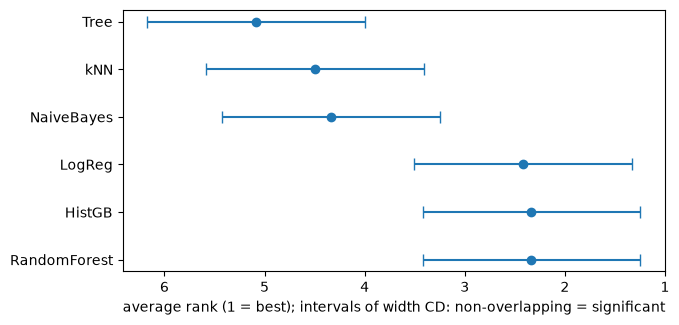

In [10]:
def friedman_nemenyi(scores, alpha=0.05):
    """Average ranks, Friedman test and Nemenyi critical difference."""
    avg_ranks = scores.rank(axis=1, ascending=False).mean().sort_values()
    chi2, p = stats.friedmanchisquare(*[scores[c] for c in scores.columns])
    N, k = scores.shape
    q_alpha = stats.studentized_range.ppf(1 - alpha, k, 1e6) / np.sqrt(2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
    return avg_ranks, chi2, p, cd


def plot_ranks(avg_ranks, cd):
    """Simple critical-difference plot: average rank with a CD-wide interval."""
    fig, ax = plt.subplots(figsize=(7, 0.4 * len(avg_ranks) + 1))
    y = np.arange(len(avg_ranks))
    ax.errorbar(avg_ranks.values, y, xerr=cd / 2, fmt="o", capsize=4)
    ax.set_yticks(y, avg_ranks.index)
    ax.invert_xaxis()
    ax.set_xlabel("average rank (1 = best); intervals of width CD: non-overlapping = significant")
    return ax


avg_ranks, chi2, p, cd = friedman_nemenyi(scores)
print(avg_ranks.round(2))
print(f"Friedman chi2 = {chi2:.1f}, p = {p:.1e}, CD = {cd:.2f}")
plot_ranks(avg_ranks, cd);

Log the benchmark to MLflow: one run per model, with the per-dataset AUC as metrics and the
average rank as a summary.

In [11]:
with mlflow.start_run(run_name="openml-benchmark"):
    mlflow.set_tag("section", "benchmark")
    mlflow.log_metrics({"friedman_chi2": chi2, "friedman_p": p, "nemenyi_cd": cd})
    for model_name in scores.columns:
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_metrics({f"auc_{d.replace('-', '_')}": v for d, v in scores[model_name].items()})
            mlflow.log_metric("avg_rank", avg_ranks[model_name])

### Try it 1: predict the winner (15 min)

1. **Before** looking at the table above, write your predicted ranking of the six models in the cell below.
2. Add one model of your own to `EXTRA_MODELS` (e.g. an RBF-SVM or an MLP from Week 6; remember scaling).
3. Run the cells: the new model is benchmarked and the ranks, Friedman test and CD are recomputed.
4. Which predictions were right? Which differences are significant?

In [12]:
# TODO: your predicted ranking, best first
my_prediction = ["...", "...", "...", "...", "...", "..."]

RandomForest    2.33
HistGB          2.33
LogReg          2.42
NaiveBayes      4.33
kNN             4.50
Tree            5.08
dtype: float64
Friedman chi2 = 27.8, p = 4.1e-05, CD = 2.18


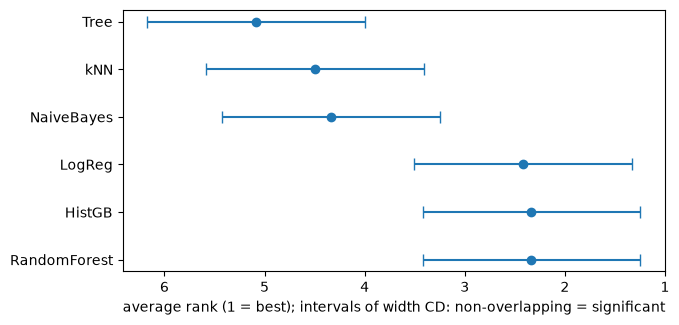

In [13]:
# TODO: add your model(s), e.g. "SVC": make_pipeline(StandardScaler(), SVC())
EXTRA_MODELS = {}

all_scores = scores.join(benchmark(EXTRA_MODELS)) if EXTRA_MODELS else scores
avg_ranks_all, chi2_all, p_all, cd_all = friedman_nemenyi(all_scores)
print(avg_ranks_all.round(2))
print(f"Friedman chi2 = {chi2_all:.1f}, p = {p_all:.1e}, CD = {cd_all:.2f}")
plot_ranks(avg_ranks_all, cd_all);

## 5. Experiment tracking with MLflow: churn prediction

The OpenML `churn` dataset: 5000 telecom customers, 14% churners. We drop `phone_number`,
an identifier that carries no signal but could let a model memorize customers.
A test set is split off and **locked** until Try it 2. All CV below uses the training part and
the same fixed splitter, so fold scores of different runs are paired.

In [14]:
churn = fetch_openml(data_id=40701, as_frame=True)
df = churn.frame.drop(columns=["phone_number"])
df["churn"] = df.pop("class").astype(int)
train_df, test_df = train_test_split(df, test_size=0.25, stratify=df["churn"], random_state=SEED)
X, y = train_df.drop(columns="churn"), train_df["churn"]
X_test_churn, y_test_churn = test_df.drop(columns="churn"), test_df["churn"]
CV = StratifiedKFold(5, shuffle=True, random_state=SEED)
N_TRAIN_FOLD, N_TEST_FOLD = len(y) - len(y) // 5, len(y) // 5
print(X.shape, y.mean().round(3))
X.dtypes.value_counts()

(3750, 19) 0.141


float64     8
int64       7
category    2
category    1
category    1
Name: count, dtype: int64

In [15]:
def get_git_commit():
    """Current Git commit, or 'unknown' outside a Git checkout."""
    try:
        return subprocess.check_output(["git", "rev-parse", "--short", "HEAD"],
                                       stderr=subprocess.DEVNULL, text=True).strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return "unknown"


git_commit = get_git_commit()
EXPERIMENT = "week08-churn"
mlflow.set_experiment(EXPERIMENT)


def log_cv_run(model, run_name, params=None, nested=False, tags=None):
    """Cross-validate `model`, log params, mean/std and per-fold ROC AUC; return fold scores."""
    with mlflow.start_run(run_name=run_name, nested=nested):
        mlflow.log_params(params or {})
        mlflow.set_tags({"git_commit": git_commit, "cv_scheme": "StratifiedKFold(5, shuffle, rs=0)",
                         "seed": SEED, **(tags or {})})
        scores = cross_val_score(model, X, y, cv=CV, scoring="roc_auc")
        for step, s in enumerate(scores):
            mlflow.log_metric("fold_roc_auc", s, step=step)
        mlflow.log_metric("cv_roc_auc_mean", scores.mean())
        mlflow.log_metric("cv_roc_auc_std", scores.std())
    return scores

2026/09/30 00:07:47 INFO mlflow.tracking.fluent: Experiment with name 'week08-churn' does not exist. Creating a new experiment.


### 5a. Logging a run (slide: *Logging a run*)

In [16]:
params = {"learning_rate": 0.1, "max_leaf_nodes": 31}
hgb_scores = log_cv_run(HistGradientBoostingClassifier(**params, random_state=0), "hgb-default", params)

preprocess = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include="category")),
    remainder=StandardScaler())
logreg = make_pipeline(preprocess, LogisticRegression(max_iter=2000))
lr_scores = log_cv_run(logreg, "logreg", {"C": 1.0})
print(f"HGB {hgb_scores.mean():.3f}   LogReg {lr_scores.mean():.3f}")

HGB 0.920   LogReg 0.855


### 5b. Autologging and dataset logging (slide: *Autologging and datasets*)

In [17]:
mlflow.sklearn.autolog()

with mlflow.start_run(run_name="hgb-autolog"):
    dataset = mlflow.data.from_pandas(train_df, name="openml-churn-40701-train", targets="churn")
    mlflow.log_input(dataset, context="training")
    HistGradientBoostingClassifier(random_state=0).fit(X, y)

mlflow.sklearn.autolog(disable=True)   # do not autolog every fit inside the search below
print("dataset digest:", dataset.digest)

2026/09/30 00:07:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/30 00:07:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


dataset digest: da2ab3ed


### 5c. Tracking an Optuna search with nested runs (slide: *Tracking a hyperparameter search*)

Each trial is a child run and logs its per-fold scores, so any trial can be compared statistically later.

In [18]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 8, 128, log=True),
    }
    scores = log_cv_run(HistGradientBoostingClassifier(**params, random_state=0),
                        f"trial-{trial.number}", params, nested=True)
    return scores.mean()


with mlflow.start_run(run_name="optuna-hgb") as parent:
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=12)
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_cv_roc_auc", study.best_value)
print(study.best_params, round(study.best_value, 4))

{'learning_rate': 0.09145320282946535, 'max_leaf_nodes': 34} 0.9219


### 5d. Comparing runs in pandas (slide: *Comparing runs in pandas*)

In [19]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT],
                          filter_string="metrics.cv_roc_auc_mean > 0.85",
                          order_by=["metrics.cv_roc_auc_mean DESC"])
cols = ["run_id", "tags.mlflow.runName", "tags.mlflow.parentRunId", "params.learning_rate",
        "params.max_leaf_nodes", "metrics.cv_roc_auc_mean", "metrics.cv_roc_auc_std"]
runs[cols].head(8)

,run_id,tags.mlflow.runName,tags.mlflow.parentRunId,params.learning_rate,params.max_leaf_nodes,metrics.cv_roc_auc_mean,metrics.cv_roc_auc_std
0,59753f8e57474f978d15913dfdddc4ce,trial-5,e38d22e2611e47fea2ffbe99f8c433bf,0.09145320282946535,34,0.921859,0.021307
1,a73afc922c994aad840383dec43dd030,trial-4,e38d22e2611e47fea2ffbe99f8c433bf,0.2438425584622684,22,0.921077,0.019822
2,ade05b5987834ac7805efeaf13f36674,hgb-default,NaN,0.1,31,0.920318,0.017656
3,44b8585e40ca4df994c4fda15b1b0217,trial-0,e38d22e2611e47fea2ffbe99f8c433bf,0.022881136684755242,57,0.918314,0.022351
4,b0b2dd2d2afd4f6da6355571e15885e4,trial-6,e38d22e2611e47fea2ffbe99f8c433bf,0.02553378845151235,104,0.918118,0.020618
5,f9e3a836d65545b2966a3fd9a63b53c1,trial-1,e38d22e2611e47fea2ffbe99f8c433bf,0.0311256170909018,35,0.917690,0.019800
6,5f8b27d2129c4a11a06afa90400170a1,trial-10,e38d22e2611e47fea2ffbe99f8c433bf,0.03289856445216643,10,0.917569,0.019587
7,adfaeffdc1784e36ad1a5cc42ba1270e,trial-9,e38d22e2611e47fea2ffbe99f8c433bf,0.08464252827630284,89,0.917473,0.019493


In [20]:
client = mlflow.MlflowClient()


def fold_scores(run_id, key="fold_roc_auc"):
    """Per-fold scores of a run, ordered by step."""
    return np.array([m.value for m in sorted(client.get_metric_history(run_id, key),
                                             key=lambda m: m.step)])


best = runs.iloc[0]
default = runs[runs["tags.mlflow.runName"] == "hgb-default"].iloc[0]
a, b = fold_scores(best.run_id), fold_scores(default.run_id)
print(f"{best['tags.mlflow.runName']} vs hgb-default: mean diff {np.mean(a - b):.4f}")
print("naive:     t={:.2f} p={:.4f}".format(*stats.ttest_rel(a, b)))
print("corrected: t={:.2f} p={:.4f}".format(*corrected_ttest(a, b, N_TRAIN_FOLD, N_TEST_FOLD)))

trial-5 vs hgb-default: mean diff 0.0015
naive:     t=0.71 p=0.5158
corrected: t=0.47 p=0.6598


With only five folds the test has little power. For a real comparison use repeated CV
(e.g. 10 x 5 folds) and log all fold scores.

### Try it 2: a tuning competition (15 min)

- Budget: **at most 20 CV evaluations** of any model on `X, y` (the training part).
- Use Optuna, random search or halving; log every evaluation with `log_cv_run(..., nested=True, tags=TEAM_TAG)`.
- Report your best CV score to the class, **then** run the test cell.
- Discussion: was your CV score optimistic? Did the CV winner also win on the test set?

In [21]:
TEAM_TAG = {"team": "your-name"}   # TODO: put your name here
BUDGET = 20


def my_objective(trial):
    # TODO: define your own search space and model (you may change the model family)
    params = {"learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True)}
    model = HistGradientBoostingClassifier(**params, random_state=0)
    return log_cv_run(model, f"{TEAM_TAG['team']}-{trial.number}", params,
                      nested=True, tags=TEAM_TAG).mean()


with mlflow.start_run(run_name=f"competition-{TEAM_TAG['team']}", tags=TEAM_TAG):
    my_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=1))
    my_study.optimize(my_objective, n_trials=3)   # TODO: use up to BUDGET trials
print("best CV ROC AUC:", round(my_study.best_value, 4), my_study.best_params)

best CV ROC AUC: 0.9236 {'learning_rate': 0.04130399570052625}


Run this cell only after you have reported your CV score.

In [22]:
from sklearn.metrics import roc_auc_score

final = HistGradientBoostingClassifier(**my_study.best_params, random_state=0).fit(X, y)
test_auc = roc_auc_score(y_test_churn, final.predict_proba(X_test_churn)[:, 1])
print(f"CV (selected) {my_study.best_value:.4f}   test {test_auc:.4f}   "
      f"optimism {my_study.best_value - test_auc:+.4f}")

CV (selected) 0.9236   test 0.9193   optimism +0.0043


### Try it 3: is it significant? (10 min)

1. Use `mlflow.search_runs` to find the two best runs (by `metrics.cv_roc_auc_mean`) in the experiment.
2. Retrieve their per-fold scores with `fold_scores(run_id)`.
3. Compare them with the naive paired t-test **and** the corrected resampled t-test.
4. Write the sentence you would put in a paper.

In [23]:
top = mlflow.search_runs(experiment_names=[EXPERIMENT],
                         filter_string="metrics.cv_roc_auc_mean > 0",
                         order_by=["metrics.cv_roc_auc_mean DESC"], max_results=2)
run_a, run_b = top.run_id.iloc[0], top.run_id.iloc[1]
a, b = fold_scores(run_a), fold_scores(run_b)
print(top[["tags.mlflow.runName", "metrics.cv_roc_auc_mean"]])

# TODO: compute the naive paired t-test and the corrected resampled t-test for a vs b
naive = None
corrected = None

# TODO: one sentence for a paper
sentence = "..."
print(naive, corrected, sentence)

  tags.mlflow.runName  metrics.cv_roc_auc_mean
0         your-name-0                 0.923623
1             trial-5                 0.921859
None None ...


## Wrap-up

- Browse all runs: `uv run mlflow ui --backend-store-uri sqlite:///mlflow.db` (run in this folder).
- In Week 12 we register the best churn model, serve it and monitor it.